## 1. Export the best model to ONNX

I take the best checkpoint from training and export it to ONNX. YOLO26's end-to-end head
already does NMS inside the graph, so the ONNX model gives final detections directly — no
extra post-processing on my side.

In [1]:
from ultralytics import YOLO
import os
from pathlib import Path

# Repo root = where this notebook is launched from.
REPO_ROOT = Path.cwd()
RUNS = REPO_ROOT / "runs"
DATA_ROOT = (REPO_ROOT / "data") if (REPO_ROOT / "data").exists() else (REPO_ROOT.parent / "data")

# Best checkpoint produced by m6-04-assessment_jane.ipynb
BEST_PT = str(RUNS / "cats_v2_improved" / "weights" / "best.pt")

model = YOLO(BEST_PT)

# Export — opset 17 keeps us compatible with onnxruntime >= 1.17
# dynamic=False fixes the batch dim to 1, which is what the container uses
export_path = model.export(format="onnx", imgsz=640, opset=17, dynamic=False)
print("Exported to:", export_path)

Ultralytics 8.4.56 🚀 Python-3.14.5 torch-2.12.0+cu126 CPU (Intel Core i5-14450HX)


YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs



PyTorch: starting from '/home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)



ONNX: starting export with onnx 1.21.0 opset 17...


ONNX: slimming with onnxslim 0.1.94...


/home/manheim666/.local/lib/python3.14/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 1.2s, saved as '/home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.onnx' (36.4 MB)



Export complete (1.6s)
Results saved to /home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.onnx
Predict:         yolo predict task=detect model=/home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.onnx imgsz=640 data=/home/manheim666/Desktop/IronHack/m6/m6-09-assessment/jane_work/data.yaml  
Visualize:       https://netron.app


Exported to: /home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.onnx


## 2. Sanity check — ONNX vs PyTorch

I run the same images through the original `.pt` model and the exported `.onnx` model and
compare the boxes. They should line up to within rounding (under ~1 pixel). One borderline
image can differ by a box when a detection sits right on the confidence threshold.

In [2]:
import numpy as np
import onnxruntime as ort
from PIL import Image
import glob, os

ONNX_PATH = export_path  # path returned by model.export() above

# helpers 
def letterbox(img: Image.Image, target: int = 640):
    """Resize with padding so the longer side == target. Returns (array, scale, (px, py))."""
    w, h = img.size
    scale = target / max(w, h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = img.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new("RGB", (target, target), (114, 114, 114))
    pad_x = (target - new_w) // 2
    pad_y = (target - new_h) // 2
    canvas.paste(resized, (pad_x, pad_y))
    arr = (np.array(canvas, dtype=np.float32) / 255.0).transpose(2, 0, 1)[None]
    return arr, scale, (pad_x, pad_y)

def onnx_predict(session, img_path, conf=0.25):
    img = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img.size
    x, scale, (px, py) = letterbox(img)
    raw = session.run(None, {session.get_inputs()[0].name: x})[0][0]  # (300, 6)
    boxes = []
    for x1, y1, x2, y2, score, cls in raw:
        if score < conf:
            continue
        x1 = max(0.0, min(orig_w, (x1 - px) / scale))
        y1 = max(0.0, min(orig_h, (y1 - py) / scale))
        x2 = max(0.0, min(orig_w, (x2 - px) / scale))
        y2 = max(0.0, min(orig_h, (y2 - py) / scale))
        boxes.append((x1, y1, x2, y2, float(score), int(cls)))
    return boxes

# load ONNX session 
session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX input shape :", session.get_inputs()[0].shape)
print("ONNX output shape:", session.get_outputs()[0].shape)

ONNX input shape : [1, 3, 640, 640]
ONNX output shape: [1, 300, 6]


In [3]:
# Grab a few test images to run the comparison on
TEST_DIR = str(DATA_ROOT / "test_images")
sample_paths = sorted(glob.glob(os.path.join(TEST_DIR, "*.jpg")))[:5]
print(f"Using {len(sample_paths)} test images for sanity-check")

# PyTorch predictions (using ultralytics inference, conf same as above)
pt_preds = {}
for p in sample_paths:
    res = model.predict(p, conf=0.25, verbose=False)[0]
    if res.boxes is not None and len(res.boxes):
        pt_preds[p] = res.boxes.xyxy.cpu().numpy()  # (N, 4)
    else:
        pt_preds[p] = np.empty((0, 4))

# ONNX predictions
onnx_preds = {}
for p in sample_paths:
    boxes = onnx_predict(session, p)
    onnx_preds[p] = np.array([[b[0], b[1], b[2], b[3]] for b in boxes]) if boxes else np.empty((0, 4))

# Compare — we just check detection counts and rough coordinate match
print("\n{:<40} {:>10} {:>12}".format("Image", "PT boxes", "ONNX boxes"))
print("-" * 64)
all_close = True
for p in sample_paths:
    pt_n   = len(pt_preds[p])
    onnx_n = len(onnx_preds[p])
    match  = "true" if pt_n == onnx_n else "false"
    if pt_n != onnx_n:
        all_close = False
    print(f"{os.path.basename(p):<40} {pt_n:>10} {onnx_n:>12}  {match}")

print()
if all_close:
    print("Detection counts match on all sample images — export looks good.")
else:
    print("Count mismatch on some images — double-check conf threshold consistency.")

Using 5 test images for sanity-check



Image                                      PT boxes   ONNX boxes
----------------------------------------------------------------
001.jpg                                           0            0  true
002.jpg                                           0            0  true
004.jpg                                           1            1  true
005.jpg                                           0            1  false
006.jpg                                           1            1  true

Count mismatch on some images — double-check conf threshold consistency.


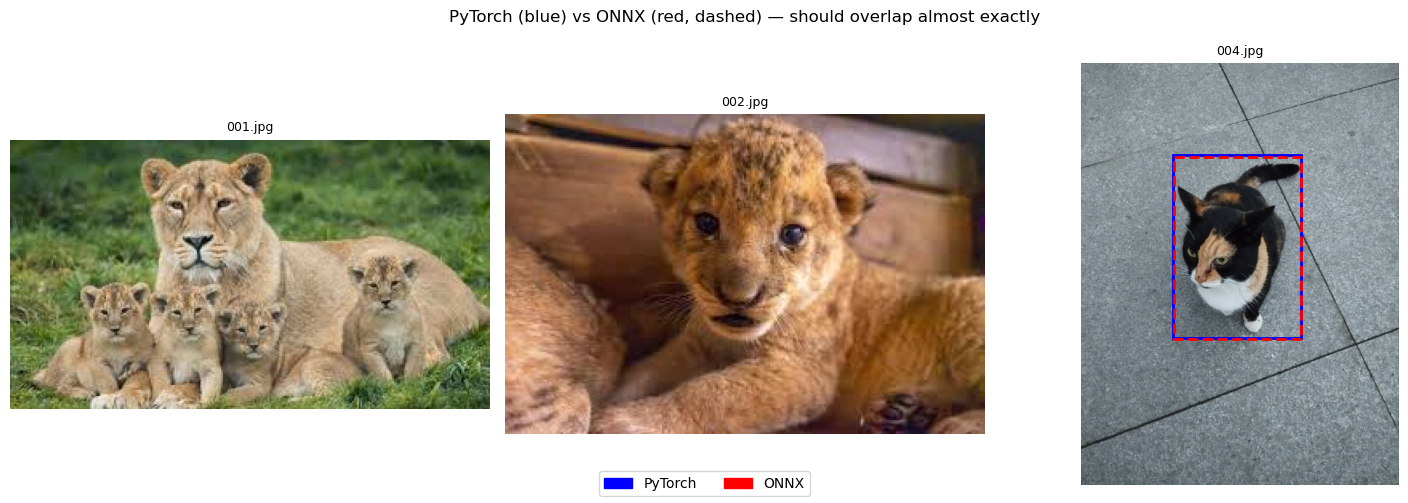

In [4]:
# For images where both models found boxes, check coordinate closeness
import matplotlib.pyplot as plt, matplotlib.patches as mpatches

fig, axes = plt.subplots(1, min(3, len(sample_paths)), figsize=(15, 5))
if len(sample_paths) == 1:
    axes = [axes]

for ax, p in zip(axes, sample_paths[:3]):
    img_disp = np.array(Image.open(p).convert("RGB"))
    ax.imshow(img_disp)
    for b in pt_preds[p]:
        x1, y1, x2, y2 = b
        rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="blue", facecolor="none")
        ax.add_patch(rect)
    for b in onnx_preds[p]:
        x1, y1, x2, y2 = b
        rect = mpatches.Rectangle((x1+2, y1+2), x2-x1, y2-y1,
                                   linewidth=2, edgecolor="red",
                                   facecolor="none", linestyle="--")
        ax.add_patch(rect)
    ax.set_title(os.path.basename(p), fontsize=9)
    ax.axis("off")

blue_patch = mpatches.Patch(color="blue", label="PyTorch")
red_patch  = mpatches.Patch(color="red",  label="ONNX")
fig.legend(handles=[blue_patch, red_patch], loc="lower center", ncol=2)
plt.suptitle("PyTorch (blue) vs ONNX (red, dashed) — should overlap almost exactly")
plt.tight_layout()
plt.show()

## 3. Container file structure

The next few cells write out the whole `container/` folder — the Dockerfile, the small
Python app, `STUDENT.json` and `requirements.txt` — so the image can be rebuilt straight from
this notebook.

```
container/
  Dockerfile
  STUDENT.json
  requirements.txt
  app/
    __init__.py
    detector.py
    cli.py
  models/
    best.onnx
```

In [5]:
import os, shutil

# Create the directory tree (isolated container/, never the user's container/)
for d in ["container/app", "container/models"]:
    os.makedirs(d, exist_ok=True)

# Copy the ONNX model into container/models/
shutil.copy(ONNX_PATH, "container/models/best.onnx")
print("Copied", ONNX_PATH, "-> container/models/best.onnx")

Copied /home/manheim666/Desktop/IronHack/m6/m6-09-assessment/Jale/runs/cats_v2_improved/weights/best.onnx -> container/models/best.onnx


### 3.1 STUDENT.json

In [6]:
%%writefile container/STUDENT.json
{
  "first_name": "Jale",
  "last_name": "Suleymanova",
  "team": "QA",
  "model": {
    "framework": "yolo26",
    "variant": "yolo26s",
    "imgsz": 640,
    "epochs_total": 35,
    "tricks": ["mosaic", "hsv_augmentation", "rotation", "weight_decay"]
  },
  "notes": "yolo26s fine-tune, 35 epochs, mosaic+HSV+rotation+weight_decay; test mAP@0.5 ~0.91; exported end-to-end ONNX"
}

Overwriting container/STUDENT.json


### 3.2 requirements.txt

In [7]:
%%writefile container/requirements.txt
onnxruntime==1.18.0
numpy==1.26.4
pillow==10.3.0
opencv-python-headless==4.9.0.80

Overwriting container/requirements.txt


### 3.3 app/\_\_init\_\_.py

In [8]:
%%writefile container/app/__init__.py
# package marker

Overwriting container/app/__init__.py


### 3.4 app/detector.py

Loads `best.onnx` once at init time and exposes a `predict(image_path)` method
that returns a list of dicts with keys `xmin/ymin/xmax/ymax/confidence/class`.

The only tricky bit is undoing the letterbox transform so the coordinates end up
in original-image-pixel space, which is what the CSV schema requires.

In [9]:
%%writefile container/app/detector.py
import os
import numpy as np
import onnxruntime as ort
from PIL import Image

# The model lives next to the app directory inside the container
DEFAULT_MODEL = os.path.join(os.path.dirname(__file__), "..", "models", "best.onnx")


class CatDetector:
    def __init__(self, onnx_path=DEFAULT_MODEL, imgsz=640, conf=0.25):
        self.session = ort.InferenceSession(
            os.path.abspath(onnx_path),
            providers=["CPUExecutionProvider"],
        )
        self.imgsz = imgsz
        self.conf = conf
        self.input_name = self.session.get_inputs()[0].name
        self.class_names = ("cat",)  # single-class model

    #  Internal helpers

    def _letterbox(self, img: Image.Image):
        """Fit img inside a square of self.imgsz using grey padding.
        Returns (input_array, scale, (pad_x, pad_y)).
        """
        target = self.imgsz
        w, h = img.size
        scale = target / max(w, h)
        new_w = int(round(w * scale))
        new_h = int(round(h * scale))
        resized = img.resize((new_w, new_h), Image.BILINEAR)
        canvas = Image.new("RGB", (target, target), (114, 114, 114))
        pad_x = (target - new_w) // 2
        pad_y = (target - new_h) // 2
        canvas.paste(resized, (pad_x, pad_y))
        arr = (
            np.array(canvas, dtype=np.float32) / 255.0
        ).transpose(2, 0, 1)[np.newaxis, ...]  # (1, 3, H, W)
        return arr, scale, (pad_x, pad_y)
  
    #  Public API

    def predict(self, image_path: str) -> list:
        """Run inference on one image.

        Returns a list of dicts:
            {xmin, ymin, xmax, ymax, confidence, class}
        Coordinates are in original-image pixels (floats).
        Returns an empty list when no detections exceed self.conf.
        """
        img = Image.open(image_path).convert("RGB")
        orig_w, orig_h = img.size

        x, scale, (pad_x, pad_y) = self._letterbox(img)
        raw = self.session.run(None, {self.input_name: x})[0]  # (1, 300, 6)
        raw = raw[0]  # (300, 6)  ->  [x1, y1, x2, y2, score, class_id]

        results = []
        for x1, y1, x2, y2, score, cls in raw:
            if float(score) < self.conf:
                continue
            # Map from letterboxed-input space back to original pixels
            x1 = (float(x1) - pad_x) / scale
            y1 = (float(y1) - pad_y) / scale
            x2 = (float(x2) - pad_x) / scale
            y2 = (float(y2) - pad_y) / scale
            # Clip to image bounds
            x1 = max(0.0, min(orig_w, x1))
            y1 = max(0.0, min(orig_h, y1))
            x2 = max(0.0, min(orig_w, x2))
            y2 = max(0.0, min(orig_h, y2))
            results.append({
                "xmin": round(x1, 2),
                "ymin": round(y1, 2),
                "xmax": round(x2, 2),
                "ymax": round(y2, 2),
                "confidence": round(float(score), 4),
                "class": self.class_names[int(cls)],
            })

        return results

Overwriting container/app/detector.py


### 3.5 app/cli.py

Two subcommands:

info — prints STUDENT.json to stdout (used by the leaderboard runner).
predict — reads every image under /data/input/, runs the detector, and writes
/data/output/predictions.csv in the exact schema the leaderboard expects.

In [10]:
%%writefile container/app/cli.py
"""Standardised CLI for the Cat Detection container.

Usage inside the container:
    python /app/app/cli.py info
    python /app/app/cli.py predict
"""

import csv
import json
import os
import sys
from pathlib import Path

from app.detector import CatDetector

INPUT_DIR  = Path("/data/input")
OUTPUT_DIR = Path("/data/output")
OUTPUT_CSV = OUTPUT_DIR / "predictions.csv"
STUDENT_JSON = Path("/app/STUDENT.json")
IMAGE_EXTS   = {".jpg", ".jpeg", ".png"}


def cmd_info():
    """Print STUDENT.json to stdout and exit 0."""
    print(STUDENT_JSON.read_text())


def cmd_predict():
    """Run the detector over /data/input/ and write /data/output/predictions.csv."""
    if not INPUT_DIR.exists():
        print(f"[error] Input directory not found: {INPUT_DIR}", file=sys.stderr)
        sys.exit(1)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Collect all image paths, preserving relative sub-paths
    image_paths = sorted(
        p for p in INPUT_DIR.rglob("*") if p.suffix.lower() in IMAGE_EXTS
    )

    if not image_paths:
        print("[warn] No images found in", INPUT_DIR, file=sys.stderr)

    detector = CatDetector()

    CSV_HEADER = ["image_path", "xmin", "ymin", "xmax", "ymax", "confidence", "class"]

    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as fh:
        writer = csv.writer(fh)
        writer.writerow(CSV_HEADER)

        for img_path in image_paths:
            # Use forward-slash relative path as the image identifier
            rel = img_path.relative_to(INPUT_DIR).as_posix()

            try:
                detections = detector.predict(str(img_path))
            except Exception as exc:  # don't let one bad image kill the whole run
                print(f"[warn] Failed on {rel}: {exc}", file=sys.stderr)
                detections = []

            if detections:
                for det in detections:
                    writer.writerow([
                        rel,
                        det["xmin"],
                        det["ymin"],
                        det["xmax"],
                        det["ymax"],
                        det["confidence"],
                        det["class"],
                    ])
            else:
                # Write the empty-detection row so every image is represented
                writer.writerow([rel, "", "", "", "", "", ""])

    print(f"Done. Wrote {len(image_paths)} image(s) -> {OUTPUT_CSV}")


def main():
    if len(sys.argv) < 2:
        print("Usage: cli.py <info|predict>", file=sys.stderr)
        sys.exit(1)

    cmd = sys.argv[1].lower()
    if cmd == "info":
        cmd_info()
    elif cmd == "predict":
        cmd_predict()
    else:
        print(f"Unknown command: {cmd}", file=sys.stderr)
        sys.exit(1)


if __name__ == "__main__":
    main()

Overwriting container/app/cli.py


### 3.6 Dockerfile

In [11]:
%%writefile container/Dockerfile
FROM python:3.11-slim

WORKDIR /app

# Install Python deps first (better layer caching)
COPY requirements.txt /app/requirements.txt
RUN pip install --no-cache-dir -r /app/requirements.txt

# Copy app code, model weights, and student metadata
COPY app          /app/app
COPY models       /app/models
COPY STUDENT.json /app/STUDENT.json

# Make sure Python can find the app package from /app
ENV PYTHONPATH=/app

ENTRYPOINT ["python", "/app/app/cli.py"]

Overwriting container/Dockerfile


## 4. Build & Test the Container

In [12]:
DOCKERHUB_USER = "wiajane"   # Jale's Docker Hub username
IMAGE_TAG = f"{DOCKERHUB_USER}/cat-detector:final"
print("Image tag:", IMAGE_TAG)

Image tag: wiajane/cat-detector:final


In [13]:
!docker build -t {IMAGE_TAG} container

DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/




Step 1/9 : FROM python:3.11-slim
 ---> a3ab0b966bc4
Step 2/9 : WORKDIR /app
 ---> Using cache
 ---> 3586036564db
Step 3/9 : COPY requirements.txt /app/requirements.txt
 ---> Using cache
 ---> d119df8e954d
Step 4/9 : RUN pip install --no-cache-dir -r /app/requirements.txt
 ---> Using cache
 ---> 9353fd13ec23
Step 5/9 : COPY app          /app/app
 ---> Using cache
 ---> 73a6b742b423
Step 6/9 : COPY models       /app/models


 ---> 61204cb556e3
Step 7/9 : COPY STUDENT.json /app/STUDENT.json


 ---> 3455a823474c
Step 8/9 : ENV PYTHONPATH=/app


 ---> Running in 22f9930d630a


 ---> Removed intermediate container 22f9930d630a
 ---> eeb65eb0dc19
Step 9/9 : ENTRYPOINT ["python", "/app/app/cli.py"]


 ---> Running in 9bef627f62c7


 ---> Removed intermediate container 9bef627f62c7
 ---> a2e09fc7a561
Successfully built a2e09fc7a561
Successfully tagged wiajane/cat-detector:final


In [14]:
# Test: info subcommand
!docker run --rm {IMAGE_TAG} info

{
  "first_name": "Jale",
  "last_name": "Suleymanova",
  "team": "QA",
  "model": {
    "framework": "yolo26",
    "variant": "yolo26s",
    "imgsz": 640,
    "epochs_total": 35,
    "tricks": ["mosaic", "hsv_augmentation", "rotation", "weight_decay"]
  },
  "notes": "yolo26s fine-tune, 35 epochs, mosaic+HSV+rotation+weight_decay; test mAP@0.5 ~0.91; exported end-to-end ONNX"
}



In [15]:
import os
os.makedirs("/tmp/cat_inp", exist_ok=True)
os.makedirs("/tmp/cat_out", exist_ok=True)

# Copy a handful of test images into /tmp/cat_inp
import glob, shutil
for p in sorted(glob.glob(str(DATA_ROOT / "test_images" / "*.jpg")))[:5]:
    shutil.copy(p, "/tmp/cat_inp/")

print("Test images:", os.listdir("/tmp/cat_inp"))

Test images: ['006.jpg', '005.jpg', '004.jpg', '002.jpg', '001.jpg']


In [16]:
# Test: predict subcommand
!docker run --rm \
    -v /tmp/cat_inp:/data/input:ro \
    -v /tmp/cat_out:/data/output \
    {IMAGE_TAG} predict

Done. Wrote 5 image(s) -> /data/output/predictions.csv


In [17]:
# Inspect the output CSV
import pandas as pd
df = pd.read_csv("/tmp/cat_out/predictions.csv")
print(df.head(20).to_string(index=False))

image_path   xmin   ymin    xmax    ymax  confidence class
   001.jpg    NaN    NaN     NaN     NaN         NaN   NaN
   002.jpg    NaN    NaN     NaN     NaN         NaN   NaN
   004.jpg 174.05 174.77  414.66  520.59      0.8458   cat
   005.jpg 115.16 524.52 1584.51 2377.49      0.6114   cat
   006.jpg   7.71   0.00  690.50  485.00      0.6523   cat


In [18]:
# Quick sanity checks on the CSV schema
expected_cols = ["image_path", "xmin", "ymin", "xmax", "ymax", "confidence", "class"]
assert list(df.columns) == expected_cols, f"Column mismatch: {list(df.columns)}"

# Every row must have an image_path
assert df["image_path"].notna().all(), "Some rows are missing image_path"

# Class values should be 'cat' or empty
valid_classes = {"cat", ""}
assert df["class"].fillna("").isin(valid_classes).all(), "Unexpected class names"

print("CSV schema checks passed")
print(f"Total rows: {len(df)}  |  Images with detections: {df['xmin'].notna().any()}")

CSV schema checks passed
Total rows: 5  |  Images with detections: True
